In [1]:
%cd ../..

/home/eli/AnacondaProjects/epych


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import collections
import glob
import functools
import logging
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import quantities as pq

import epych
from epych.statistics import alignment

[striatum:198755] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.striatum.1000/jf.0/1208025088/shared_mem_cuda_pool.striatum could be created.
[striatum:198755] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 


In [4]:
%matplotlib inline

In [5]:
logging.basicConfig(level=logging.INFO)

In [6]:
CONDITIONS = ["go_gloexp", "go_seqctl", "lo_gloexp", "lonaive", "lo_rndctl", "igo_seqctl"]
PRETRIAL_SECONDS = 0.5
POSTTRIAL_SECONDS = 0.5

In [7]:
NWB_SUBJECTS = glob.glob('/mnt/data/000253/sub-*/')

In [8]:
PILOT_FILES = []

In [9]:
NUM_TRIALS = 0
ODDBALL_ONSET = 0.
ODDBALL_OFFSET = 0.

In [10]:
evoked = {}

In [11]:
aligner = epych.statistics.alignment.AlignmentSummary.unpickle("/mnt/data/000253/visual_alignment")

In [12]:
def visual_align(signal):
    return signal.select_channels(["VIS" in loc for loc in signal.channels.location]).median_filter()

In [13]:
def samplings():
    for s, subject_dir in enumerate(sorted(NWB_SUBJECTS)):
        subject = subject_dir.split('/')[-2]
        if not os.path.exists(subject_dir + "/" + cond):
            continue
        
        sampling = epych.recording.Sampling.unpickle(subject_dir + "/" + cond).smap(visual_align)
        global ODDBALL_ONSET
        global ODDBALL_OFFSET
        global NUM_TRIALS
        ODDBALL_ONSET += sampling.trials['stim3_start'].sum()
        ODDBALL_OFFSET += sampling.trials['stim3_end'].sum()
        NUM_TRIALS += len(sampling.trials)
        yield sampling
        del sampling
        logging.info("Loaded LFPs for %s in subject %s" % (cond, subject))

In [14]:
trialwise_variances = {cond: {area: None for area in aligner.stats.keys()} for cond in CONDITIONS}

In [15]:
for cond in CONDITIONS:
    cond_lfps = samplings(cond)
    for (area, signal) in cond_lfps.signals.items():
        trialwise_variances[cond][area] = signal.data.magnitude.var(axis=(0, 1)) * (signal.data.units ** 2)
    del cond_lfps
    logging.info("Calculated trialwise variances for LFPs in condition %s" % cond)

INFO:root:Loading LFPs for condition go_gloexp
INFO:root:Loaded LFPs for condition go_gloexp, baseline from (-3.502630, -3.002630)
INFO:root:Calculated trialwise variances for LFPs in condition go_gloexp
INFO:root:Loading LFPs for condition go_seqctl
INFO:root:Loaded LFPs for condition go_seqctl, baseline from (-3.502532, -3.002532)
INFO:root:Calculated trialwise variances for LFPs in condition go_seqctl
INFO:root:Loading LFPs for condition lo_gloexp
INFO:root:Loaded LFPs for condition lo_gloexp, baseline from (-3.502310, -3.002310)
INFO:root:Calculated trialwise variances for LFPs in condition lo_gloexp
INFO:root:Loading LFPs for condition lonaive
INFO:root:Loaded LFPs for condition lonaive, baseline from (-3.502524, -3.002524)
INFO:root:Calculated trialwise variances for LFPs in condition lonaive
INFO:root:Loading LFPs for condition lo_rndctl
INFO:root:Loaded LFPs for condition lo_rndctl, baseline from (-3.502524, -3.002524)
INFO:root:Calculated trialwise variances for LFPs in condit

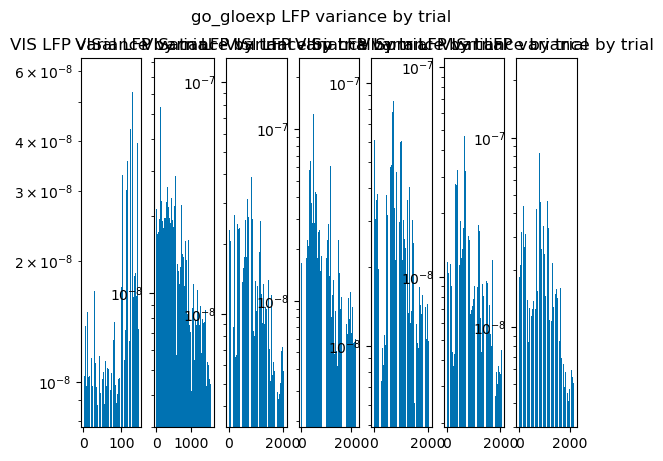

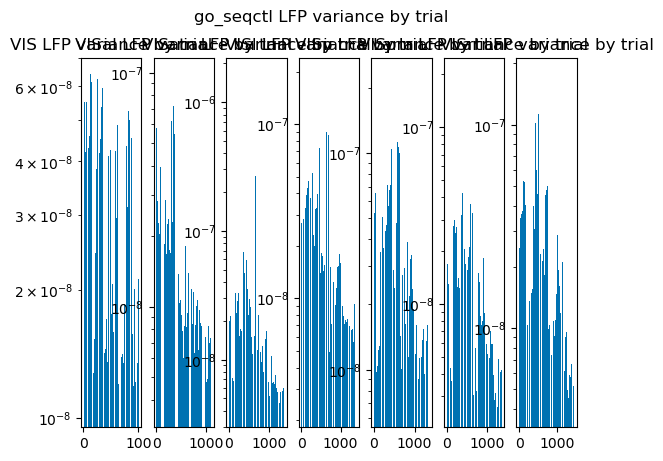

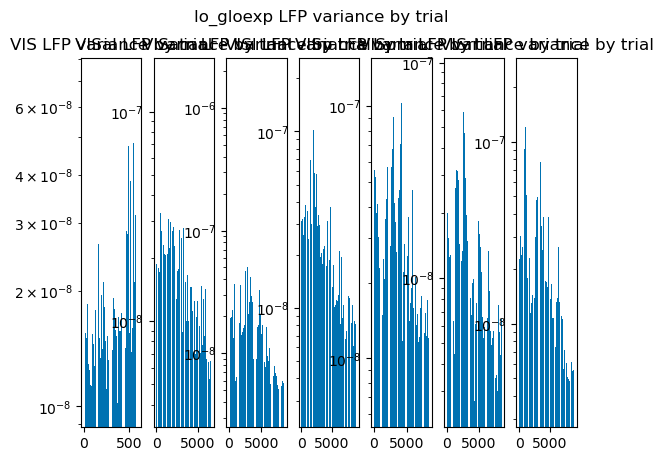

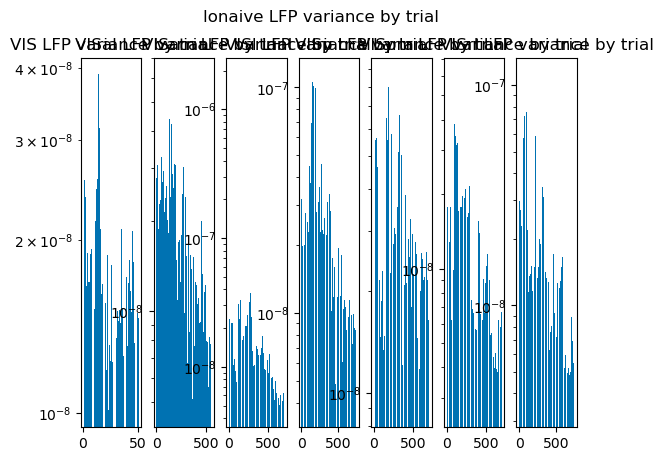

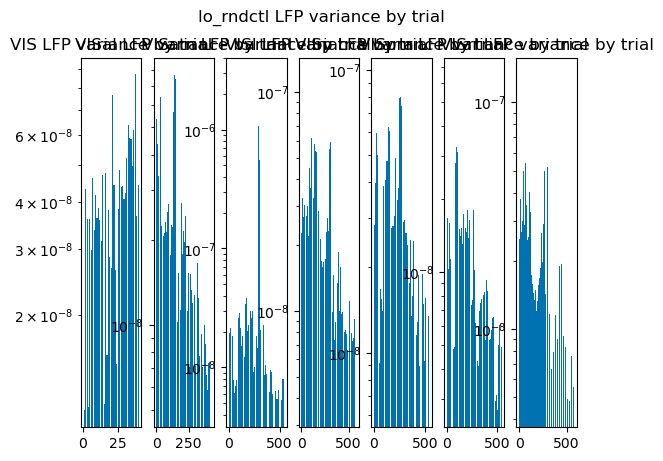

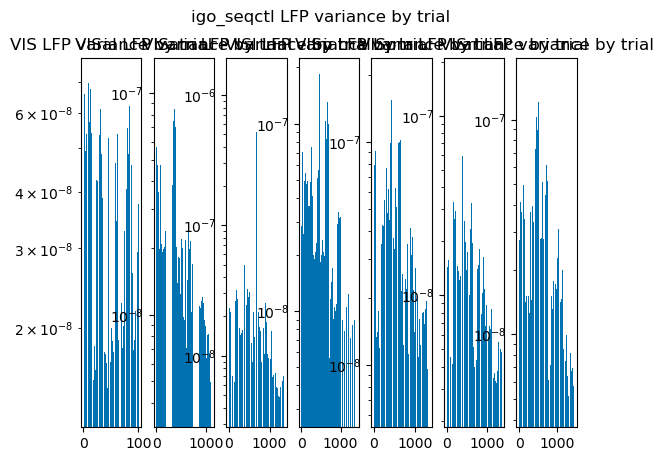

In [16]:
for cond in CONDITIONS:
    fig, axes = plt.subplot_mosaic([list(trialwise_variances[cond].keys())], layout=)
    fig.suptitle(cond + " LFP variance by trial")

    for area, ax in axes.items():
        num_trials = len(trialwise_variances[cond][area])
        ax.bar(np.arange(num_trials) + 1, trialwise_variances[cond][area].magnitude)
        ax.set_yscale('log')
        ax.set_title(area + " LFP variance by trial")

    plt.show()